## Importando as bibliotecas necessárias

In [17]:
import os
from requests import post, get
import json
from base64 import b64encode
from dotenv import load_dotenv
load_dotenv()

from time import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Definindo as variáveis iniciais

In [18]:
client_id = os.environ['CLIENT_ID_SPOTIFY']
client_secret = os.environ['CLIENT_SECRET_SPOTIFY']
base_url = 'https://accounts.spotify.com'
endpoint = '/api/token'
redirect_uri = 'http://localhost:3000'

## Criando as funções para acesso
### Requisitando a autorização

In [19]:
def request_auth():
    b64_encoded = b64encode(f'{client_id}:{client_secret}'.encode())
    auth_b64 = str(b64_encoded, 'utf-8')
    
    auth_options = {
        'url': base_url + endpoint,
        'headers':{
            'Authorization': 'Basic ' + auth_b64,
            'content-type': 'application/x-www-form-urlencoded'
        },
        'form':{
            'redirect_uri': redirect_uri,
            'grant_type': 'client_credentials'
        },
        'json': True
    }

    request = post(url=auth_options['url'], headers=auth_options['headers'], data=auth_options['form'])
    if request.status_code == 200:
        json_request = request.json()
        access_token = json_request['access_token']
        token_type = json_request['token_type']
        token_expires = json_request['expires_in']
        print('Acesso autorizado e dados extraídos!')
    else:
        print('Acesso não autorizado!')
        
    return access_token, token_type, token_expires

In [20]:
access_token, token_type, token_expires = request_auth()

Acesso autorizado e dados extraídos!


In [21]:
access_token, token_type

('BQB0ceYICnvtJExOuEXoeNs8D6XPhH00SFA_L676ztfzbpdfVdlulVCAm8kEuO6rrfCS6hdglMLTp6fsf7tUupScjDn3aVEfxS1XgMVFsvlU7_DMrsk',
 'Bearer')

### Extraindo a playlist

In [22]:
def get_playlist(playlist, token_type, access_token, offset=0, limit=100):
    playlist_id = playlist.split('/')[-1].split('?')[0]
    endpoint = f'https://api.spotify.com/v1/playlists/{playlist_id}/tracks?offset={str(offset)}&limit={str(limit)}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    response = get(url=endpoint, headers=headers)

    return response.json()

### Extraindo as features da música

In [23]:
def track_features(track_id, token_type, access_token):
    endpoint = f'https://api.spotify.com/v1/audio-features/{track_id}'
    headers={
        'Authorization': token_type + ' ' + access_token
    }

    response = get(url=endpoint, headers=headers)
    print(response.status_code)
    
    if response.status_code == 200:
        print('Dados extraídos com sucesso!')
    else:
        print('Dados não extraidos!')

    return response.json()

### Transformando o json retornado da `get_playlist` em um DataFrame do `pandas`.

In [24]:
def json_to_dataframe(playlist_endpoint, token_type, access_token, offset=0, limit=100, label=None):
    """
    Input's a json and returns a pandas DataFrame
    """
    examples = []
    df = 10
    playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=offset, limit=limit)
    m = len(playlist['items'])
    
    for page in range(limit, playlist['total'] + 1, limit):
        for i in range(len(playlist['items'])):
            track = playlist['items'][i]['track']
            track_feature = track_features(track['id'], token_type, access_token)


            # Lista para adicionar cada exemplo
            example = [
                track['id'],
                track['name'],
                track['artists'][0]['name'],
                track['duration_ms'],
                track['popularity'],
                track_feature['danceability'],
                track_feature['energy'],
                track_feature['key'],
                track_feature['loudness'],
                track_feature['mode'],
                track_feature['speechiness'],
                track_feature['acousticness'],
                track_feature['instrumentalness'],
                track_feature['liveness'],
                track_feature['valence'],
                track_feature['tempo']
            ]


            examples.append(example)
        
        playlist = get_playlist(playlist=playlist_endpoint, token_type=token_type, access_token=access_token, offset=page, limit=limit)
        print(f'offset: {page}')
    
    features = ['id', 'name', 'artists', 'duration_ms', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
               'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
    df = pd.DataFrame(examples, columns=features)
    
    if label == 0:
        df['y'] = 0
    elif label == 1:
        df['y'] = 1
    
    return df, playlist

In [25]:
good_songs = 'https://open.spotify.com/playlist/6DI0NiX9bE3fIF6cEoI2zL?si=ef8a610d53f64627'
bad_songs = 'https://open.spotify.com/playlist/6IBody2iNg5TgmAeYiHYpW?si=xsEvNjbbQYqt0rs9wP3yOg'

### Good Songs

In [ ]:
df_good, playlist = json_to_dataframe(good_songs, token_type, access_token, offset=0, limit=100, label=1)
df_good.shape, playlist['items'][13]

In [26]:
playlist = get_playlist(good_songs, token_type, access_token)
track = track_features(playlist['items'][0]['track']['id'], token_type, access_token)
track

429
Dados não extraidos!


{'error': {'status': 429}}

In [ ]:
df_good['artists'].value_counts().sort_values(ascending=False)

In [ ]:
print(f'Duração média: {np.mean(df_good["duration_ms"]) / 60:.2f}min\nPopularidade média: {np.mean(df_good["popularity"]):.1f}')

### Bad Songs

In [ ]:
df_bad, _ = json_to_dataframe(bad_songs, token_type, access_token, offset=0, limit=100, label=0)
df_bad

In [ ]:
df_bad['artists'].value_counts().sort_values(ascending=False)

In [ ]:
print(f'Duração média: {np.mean(df_bad["duration_ms"]) / 60:.2f}min\nPopularidade média: {np.mean(df_bad["popularity"])}')

## EDA

### Popularity

Text(0.5, 1.0, 'Good vs Bad Popularity')

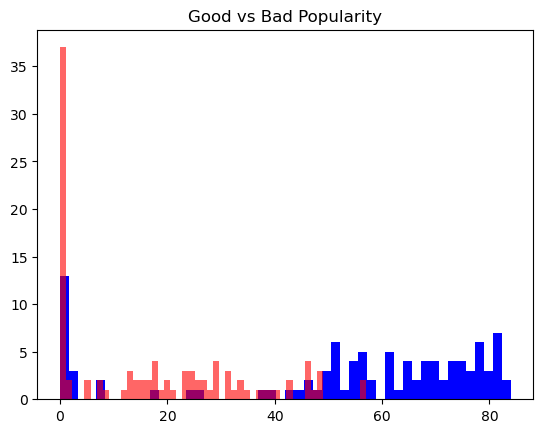

In [180]:
plt.hist(df_good['popularity'], color='b', bins=50)
plt.hist(df_bad['popularity'], alpha=0.6, color='r', bins=50)
plt.title('Good vs Bad Popularity')

### Duration ms

Text(0.5, 1.0, 'Good vs Bad Duration')

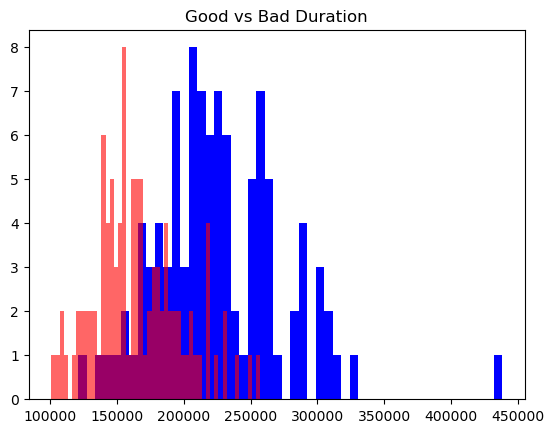

In [181]:
plt.hist(df_good['duration_ms'], color='b', bins=50)
plt.hist(df_bad['duration_ms'], alpha=0.6, color='r', bins=50)
plt.title('Good vs Bad Duration')

In [234]:
features = ['id', 'name', 'popularity', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']
good = df_good[features]
good

,id,name,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,1XNdu4czbxZ9tdVOhDtI4M,Cheia de Manias,51,0.707,0.614,7,-9.377,0,0.0580,0.198000,0.000000,0.1770,0.957,156.473
1,1SaeGiWS1LQhfRc6ObQfvq,Que Se Chama Amor,0,0.647,0.528,7,-12.739,1,0.0409,0.411000,0.000000,0.0481,0.621,136.118
2,6jBZxE0VZpmgZud4L5lo0u,Paparico,54,0.738,0.850,9,-7.278,1,0.0756,0.530000,0.000000,0.2130,0.967,88.799
3,43uHeQc9kdMzFAbxCTcgiI,Telegrama,54,0.517,0.516,11,-12.441,1,0.0342,0.443000,0.000004,0.2360,0.601,151.060
4,4tILvSk9XcdCBzjyzhsuze,É Tarde Demais,50,0.615,0.403,4,-11.648,1,0.0282,0.425000,0.000004,0.3210,0.454,136.377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,3jJZVeExYzVYiV6Y9Fl3DX,Plush,64,0.423,0.954,7,-3.157,0,0.0470,0.002100,0.000000,0.1770,0.500,144.553
96,5UWwZ5lm5PKu6eKsHAGxOk,Everlong,81,0.413,0.881,11,-5.541,0,0.0367,0.000060,0.000308,0.0805,0.364,158.066
97,6b2oQwSGFkzsMtQruIWm2p,Creep,24,0.515,0.430,7,-9.935,1,0.0369,0.010200,0.000141,0.1290,0.104,91.841
98,5qqabIl2vWzo9ApSC317sa,Wonderwall - Remastered,78,0.376,0.896,2,-4.065,1,0.0395,0.000452,0.000000,0.1940,0.472,174.379


In [236]:
corr_good = good.iloc[:, 2:].corr()
corr_good

,popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo
popularity,1.000000,0.067757,0.126401,-0.150757,0.269411,-0.069206,0.148434,-0.248052,-0.107428,-0.153134,0.111011,0.060010
danceability,0.067757,1.000000,-0.266757,-0.003222,-0.159029,0.222444,-0.092200,0.165407,0.010736,-0.165431,0.334021,-0.231930
energy,0.126401,-0.266757,1.000000,-0.123715,0.766703,-0.244514,0.354713,-0.788201,0.022558,0.131022,0.391377,0.011292
key,-0.150757,-0.003222,-0.123715,1.000000,-0.138626,-0.154062,-0.057987,0.153602,-0.078316,-0.016031,0.058853,0.125194
loudness,0.269411,-0.159029,0.766703,-0.138626,1.000000,-0.249845,0.259511,-0.698026,-0.032255,-0.003244,0.304308,-0.010495
mode,-0.069206,0.222444,-0.244514,-0.154062,-0.249845,1.000000,-0.075863,0.239228,0.142998,0.011747,0.081781,-0.073312
speechiness,0.148434,-0.092200,0.354713,-0.057987,0.259511,-0.075863,1.000000,-0.273173,-0.028948,0.074888,0.187882,-0.109779
acousticness,-0.248052,0.165407,-0.788201,0.153602,-0.698026,0.239228,-0.273173,1.000000,-0.096871,0.016622,-0.270815,-0.021931
instrumentalness,-0.107428,0.010736,0.022558,-0.078316,-0.032255,0.142998,-0.028948,-0.096871,1.000000,-0.079854,-0.050522,-0.030543
liveness,-0.153134,-0.165431,0.131022,-0.016031,-0.003244,0.011747,0.074888,0.016622,-0.079854,1.000000,0.004643,0.200853
